**Relative Abundance Analysis of Gut Microbiome Across AD, MCI, and Healthy Samples**

This notebook performs genus-level relative abundance (RA) analysis of gut microbiome samples across three conditions: Alzheimer's Disease (AD), Mild Cognitive Impairment (MCI),
and Healthy controls. The workflow includes preprocessing, calculation of mean relative abundances, prevalence filtering, standardization, and principal component analysis (PCA).

Visualization of PCA scores and selection of genera with the highest inter-condition variability (ICR) are also included for downstream analysis.


In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
from pathlib import Path
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

Pre-Processing and Sample Statistics

In [ ]:
# Read the relative abundance files into varaibles named after corresponding sample conditions
ad_rel_abd = pd.read_csv('/content/drive/MyDrive/MICOM/ad_rel_abd_frmt.csv')
mci_rel_abd = pd.read_csv('/content/drive/MyDrive/MICOM/mci_rel_abd_frmt.csv')
healthy_rel_abd = pd.read_csv('/content/drive/MyDrive/MICOM/healthy_rel_abd_frmt.csv')

In [ ]:
print("AD Relative Abundance")
print(ad_rel_abd.head())
print()
print("MCI Relative Abundance")
print(mci_rel_abd.head())
print()
print("Healthy Relative Abundance")
print(healthy_rel_abd.head())

AD Relative Abundance
                  id              genus   sample_id  abundance
0        Escherichia        Escherichia  SRR8061715   0.000000
1       Ruminococcus       Ruminococcus  SRR8061715   0.000000
2    Bifidobacterium    Bifidobacterium  SRR8061715   0.105002
3        Eubacterium        Eubacterium  SRR8061715   0.033799
4  Ligilactobacillus  Ligilactobacillus  SRR8061715   0.005408

MCI Relative Abundance
                id            genus   sample_id  abundance
0      Eubacterium      Eubacterium  SRR8061735   0.000000
1      Bacteroides      Bacteroides  SRR8061735   0.095480
2  Bifidobacterium  Bifidobacterium  SRR8061735   0.006919
3     Anaerostipes     Anaerostipes  SRR8061735   0.000000
4     Agathobacter     Agathobacter  SRR8061735   0.018450

Healthy Relative Abundance
                    id                genus   sample_id  abundance
0              Unknown              Unknown  SRR8061745   0.003647
1          Escherichia          Escherichia  SRR8061745   0.

In [ ]:
# Total number of genera per condition (including Unknown)
# Convert genus columns to sets (to allow for set operations)
# From genus column: drop NaN, find all unique values
ad_total_genera = set(ad_rel_abd["genus"].dropna().unique())
mci_total_genera = set(mci_rel_abd["genus"].dropna().unique())
healthy_total_genera = set(healthy_rel_abd["genus"].dropna().unique())

# Remove "Unknown" (unclassified genera) from genera sets
ad_identified_genera = ad_total_genera - set(["Unknown"])
mci_identified_genera = mci_total_genera - set(["Unknown"])
healthy_identified_genera = healthy_total_genera - set(["Unknown"])

In [ ]:
print("Number of Identified Genera in AD Samples:", len(ad_identified_genera))
print()
print("Number of Identified Genera in MCI Samples:", len(mci_identified_genera))
print()
print("Number of Identified Genera in Healthy Samples:", len(healthy_identified_genera))

Number of Identified Genera in AD Samples: 84

Number of Identified Genera in MCI Samples: 95

Number of Identified Genera in Healthy Samples: 87


In [ ]:
# Use set subtraction to find genera unique to each condition
unique_to_ad = ad_identified_genera - mci_identified_genera - healthy_identified_genera
unique_to_mci = mci_identified_genera - ad_identified_genera - healthy_identified_genera
unique_to_healthy = healthy_identified_genera - ad_identified_genera - mci_identified_genera

In [ ]:
print("Number of genera unique to AD: ", len(unique_to_ad))
print(sorted(unique_to_ad))
print()
print("Number of genera unique to MCI: ", len(unique_to_mci))
print(sorted(unique_to_mci))
print()
print("Number of genera unique to Healthy: ", len(unique_to_healthy))
print(sorted(unique_to_healthy))

Number of genera unique to AD:  7
['Chloroplast', 'Conservatibacter', 'DTU089', 'Eisenbergiella', 'Negativibacillus', 'Paludicola', 'Vicinamibacteraceae']

Number of genera unique to MCI:  10
['Acinetobacter', 'Alloprevotella', 'Coprobacter', 'Hydrogenoanaerobacterium', 'Izemoplasmatales', 'Leptotrichia', 'Pediococcus', 'Proteus', 'RF39', 'Tuzzerella']

Number of genera unique to Healthy:  3
['Oxalobacter', 'Rothia', 'Sellimonas']


In [ ]:
# Remove rows where genus is "Unknown" in relative abundance dataframes
ad_rel_abd = ad_rel_abd[ad_rel_abd["genus"] != "Unknown"].copy()
mci_rel_abd = mci_rel_abd[mci_rel_abd["genus"] != "Unknown"].copy()
healthy_rel_abd = healthy_rel_abd[healthy_rel_abd["genus"] != "Unknown"].copy()

Mean Relative Abundance (MRA)

In [ ]:
# Did not use top genera (highest abundance) in each condition because they were similar
# across conditions. This is expected as they are likely commom human gut microbes, but
# they do not provide insight into disease causing microbes. Instead we compared which
# genera differed the most in mean relative abundance accross the conditions.

In [ ]:
# Group rows by genus, find mean relative abundance across all samples for each condition,
# (index = genus, value = mean relative abundance)
ad_mean = ad_rel_abd.groupby("genus")["abundance"].mean()
mci_mean = mci_rel_abd.groupby("genus")["abundance"].mean()
healthy_mean = healthy_rel_abd.groupby("genus")["abundance"].mean()

# Merge into single dataframe
mean_abundance = pd.concat([ad_mean, mci_mean, healthy_mean], axis = 1)
mean_abundance.columns = ["AD Mean", "MCI Mean", "Healthy Mean"]

In [ ]:
print(mean_abundance.head())

                  AD Mean  MCI Mean  Healthy Mean
genus                                            
Acidaminococcus  0.003836  0.003905      0.001665
Adlercreutzia    0.000553  0.000057      0.000392
Agathobacter     0.012879  0.010839      0.011471
Alistipes        0.013676  0.039401      0.016895
Anaerostipes     0.011775  0.019478      0.018644


In [ ]:
# Inter-condition range (ICR) of mean relative abundance
# For each genus, calculate the difference (ICR) between the largest (max) and smallest (min) mean relative
# abundance across the AD, MCI, and Healthy conditions (columns, axis = 1). A high inter-condition range
# indicates a genus differs substantially between conditions.
mean_abundance["ICR"] = mean_abundance.max(axis = 1) - mean_abundance.min(axis = 1)

# Sort genera by ICR from highest to lowest
icr = mean_abundance.sort_values("ICR", ascending = False)
print(icr.head(20))


                        AD Mean  MCI Mean  Healthy Mean       ICR
genus                                                            
Escherichia            0.211318  0.068633      0.108680  0.142685
Bacteroides            0.072658  0.166486      0.070809  0.095677
Blautia                0.082860  0.073037      0.124532  0.051495
Alistipes              0.013676  0.039401      0.016895  0.025725
Limosilactobacillus    0.025877  0.005967      0.003137  0.022739
Megamonas              0.020195  0.003351      0.003020  0.017175
Phascolarctobacterium  0.028079  0.034946      0.019331  0.015615
Veillonella            0.020858  0.021278      0.006047  0.015231
Streptococcus          0.027998  0.013020      0.020321  0.014978
Romboutsia             0.015647  0.017156      0.030187  0.014540
Ligilactobacillus      0.021427  0.008336      0.009374  0.013091
Bifidobacterium        0.025698  0.021446      0.013431  0.012268
Clostridium            0.004188  0.004971      0.015255  0.011066
Subdoligra

In [ ]:
# Differences in MRA between conditions.
# Healthy vs AD: + means Healthy > AD, - means Healthy < AD
mean_abundance["Healthy vs AD"] = mean_abundance["Healthy Mean"] - mean_abundance["AD Mean"]
# Healthy vs MCI: + means Healthy > MCI, - means Healthy < MCI
mean_abundance["Healthy vs MCI"] = mean_abundance["Healthy Mean"] - mean_abundance["MCI Mean"]
# MCI vs AD: + means MCI > AD, - means MCI < AD
mean_abundance["MCI vs AD"] = mean_abundance["MCI Mean"] - mean_abundance["AD Mean"]

In [ ]:
# Sort by ascending to find genera that are more abundant in AD than healthy samples.
top_ad = mean_abundance.sort_values("Healthy vs AD").head(10)
print(top_ad[["AD Mean", "Healthy Mean", "Healthy vs AD"]])

                        AD Mean  Healthy Mean  Healthy vs AD
genus                                                       
Escherichia            0.211318      0.108680      -0.102638
Limosilactobacillus    0.025877      0.003137      -0.022739
Megamonas              0.020195      0.003020      -0.017175
Veillonella            0.020858      0.006047      -0.014811
Bifidobacterium        0.025698      0.013431      -0.012268
Ligilactobacillus      0.021427      0.009374      -0.012053
Phascolarctobacterium  0.028079      0.019331      -0.008748
Streptococcus          0.027998      0.020321      -0.007678
Roseburia              0.010285      0.007110      -0.003175
Lactobacillus          0.004128      0.000977      -0.003151


In [ ]:
# Sort by ascending to find genera that are more abundant in MCI than healthy samples.
top_mci = mean_abundance.sort_values("Healthy vs MCI").head(10)
print(top_mci[["MCI Mean", "Healthy Mean", "Healthy vs MCI"]])

                       MCI Mean  Healthy Mean  Healthy vs MCI
genus                                                        
Bacteroides            0.166486      0.070809       -0.095677
Alistipes              0.039401      0.016895       -0.022506
Phascolarctobacterium  0.034946      0.019331       -0.015615
Veillonella            0.021278      0.006047       -0.015231
Parabacteroides        0.017442      0.008496       -0.008945
Bifidobacterium        0.021446      0.013431       -0.008015
Faecalibacterium       0.056321      0.049564       -0.006758
Megasphaera            0.007044      0.000471       -0.006573
Muribaculaceae         0.005862      0.000137       -0.005724
Roseburia              0.012265      0.007110       -0.005155


In [ ]:
# Sort by ascending to find genera that are more abundant in AD than MCI samples.
top_ad_mci = mean_abundance.sort_values("MCI vs AD").head(10)
print(top_ad_mci[["MCI Mean", "AD Mean", "MCI vs AD"]])

                     MCI Mean   AD Mean  MCI vs AD
genus                                             
Escherichia          0.068633  0.211318  -0.142685
Limosilactobacillus  0.005967  0.025877  -0.019909
Megamonas            0.003351  0.020195  -0.016844
Streptococcus        0.013020  0.027998  -0.014978
Ligilactobacillus    0.008336  0.021427  -0.013091
Blautia              0.073037  0.082860  -0.009824
Dorea                0.007400  0.013657  -0.006257
Bifidobacterium      0.021446  0.025698  -0.004252
Enterobacter         0.003955  0.007537  -0.003582
Lactobacillus        0.001369  0.004128  -0.002758


Principle Component Analysis

In [ ]:
# Add condition identification label to each relative abundance dataframe.
ad_rel_abd["condition"] = "AD"
mci_rel_abd["condition"] = "MCI"
healthy_rel_abd["condition"] = "Healthy"

# Merge all relative abundances tables into a single dataframe and reset index.
relative_abundance = pd.concat([ad_rel_abd, mci_rel_abd, healthy_rel_abd], ignore_index = True)

In [ ]:
print(relative_abundance.head())

                  id              genus   sample_id  abundance condition
0        Escherichia        Escherichia  SRR8061715   0.000000        AD
1       Ruminococcus       Ruminococcus  SRR8061715   0.000000        AD
2    Bifidobacterium    Bifidobacterium  SRR8061715   0.105002        AD
3        Eubacterium        Eubacterium  SRR8061715   0.033799        AD
4  Ligilactobacillus  Ligilactobacillus  SRR8061715   0.005408        AD


In [ ]:
# Create a column to track which genera are present/absent.
# True if RA > 0, or False if RA == 0
relative_abundance["present"] = relative_abundance["abundance"] > 0

# Calculate prevalance: For each (condition, genus) group, find mean:
# (number of samples where genus present/number of samples in condition)
prevalence = relative_abundance.groupby(["condition", "genus"])["present"].mean()
# Reset the index.
prevalence = prevalence.reset_index()
# Change to wide format.
prevalence = prevalence.pivot(
    index = "genus",
    columns = "condition",
    values = "present").fillna(0.0)
# Rename columns.
prevalence = prevalence.rename(columns={
    "AD": "AD Prevalence",
    "MCI": "MCI Prevalence",
    "Healthy": "Healthy Prevalence"})

print(prevalence.head())

condition        AD Prevalence  Healthy Prevalence  MCI Prevalence
genus                                                             
Acidaminococcus       0.090909            0.071429         0.09375
Acinetobacter         0.000000            0.000000         0.03125
Adlercreutzia         0.060606            0.035714         0.03125
Agathobacter          0.333333            0.285714         0.37500
Akkermansia           0.000000            0.142857         0.06250


In [ ]:
# If genera has prevalence >= 10% in AD or MCI or Healthy samples, filter_genera == True.
filter_genera = (
    (prevalence["AD Prevalence"] >= 0.10) |
    (prevalence["MCI Prevalence"] >= 0.10) |
    (prevalence["Healthy Prevalence"] >= 0.10))

# Store names of prevalent genera in filtered list.
filtered = prevalence[filter_genera].index

print("\nNumber of genera after per-condition prevalence filter:", len(filtered))


Number of genera after per-condition prevalence filter: 62


In [ ]:
# Change long relative abundance table to wide matrix format:
#      rows (index) = sample id
#      columns = genera
#      cell values = relative abundance
rel_abd_matrix = relative_abundance.pivot_table(
    index = "sample_id",
    columns = "genus",
    values = "abundance",
    fill_value = 0.0)         # for missing values use 0.0

In [ ]:
# Keep only prevalent genera.
rel_abd_matrix = rel_abd_matrix[filtered]

print("Relative Abundance Matrix:")
print("size -", rel_abd_matrix.shape)
print(rel_abd_matrix.head())

Relative Abundance Matrix:
size - (93, 62)
genus       Agathobacter  Akkermansia  Alistipes  Alloprevotella  \
sample_id                                                          
SRR8061715           0.0          0.0   0.000000             0.0   
SRR8061716           0.0          0.0   0.000000             0.0   
SRR8061717           0.0          0.0   0.011285             0.0   
SRR8061718           0.0          0.0   0.000000             0.0   
SRR8061719           0.0          0.0   0.000000             0.0   

genus       Anaerostipes  Bacteroides  Barnesiella  Bifidobacterium   Blautia  \
sample_id                                                                       
SRR8061715      0.000000     0.000000          0.0         0.105002  0.061740   
SRR8061716      0.009767     0.030804          0.0         0.021037  0.084899   
SRR8061717      0.008247     0.039062          0.0         0.000000  0.057726   
SRR8061718      0.000000     0.000000          0.0         0.018788  0.0117

In [ ]:
# Standardization:
# Create scaler object.
scaler = StandardScaler()
# Fit scaler: Calculate mean and standard deviation for each genus.
scaler.fit(rel_abd_matrix)
# Transform rel_abd_matrix: Calcualte z-scores = (RA - mean)/standard deviation.
rel_abd_scaled = scaler.transform(rel_abd_matrix)
# Covert back to dataframe.
rel_abd_scaled = pd.DataFrame(rel_abd_scaled, columns = rel_abd_matrix.columns, index = rel_abd_matrix.index)

print(rel_abd_scaled.head())

genus       Agathobacter  Akkermansia  Alistipes  Alloprevotella  \
sample_id                                                          
SRR8061715     -0.591511    -0.186366  -0.730649       -0.157762   
SRR8061716     -0.591511    -0.186366  -0.730649       -0.157762   
SRR8061717     -0.591511    -0.186366  -0.379744       -0.157762   
SRR8061718     -0.591511    -0.186366  -0.730649       -0.157762   
SRR8061719     -0.591511    -0.186366  -0.730649       -0.157762   

genus       Anaerostipes  Bacteroides  Barnesiella  Bifidobacterium   Blautia  \
sample_id                                                                       
SRR8061715     -0.567608    -0.920653    -0.389039         2.469189 -0.383421   
SRR8061716     -0.231487    -0.648973    -0.389039         0.014477 -0.090236   
SRR8061717     -0.283815    -0.576134    -0.389039        -0.600530 -0.434235   
SRR8061718     -0.567608    -0.920653    -0.389039        -0.051262 -1.016364   
SRR8061719     -0.567608    -0.920653

In [ ]:
# Run PCA to reduce high-dimensional dataset into 3 principal components.
pca = PCA(n_components = 3)
# Fit: Find axes (components) where variance is greatest.
pca.fit(rel_abd_scaled)
# Transform: Project samples onto learned principal axes (components).
pca_scores = pca.transform(rel_abd_scaled)

# Find how much of the variance is explained by each principal component.
pc_variance = pca.explained_variance_ratio_
print(f"PC1: {(pc_variance[0]*100):.1f}%")
print(f"PC2: {(pc_variance[1]*100):.1f}%")
print(f"PC3: {(pc_variance[2]*100):.1f}%")

# Find how much of the variance is explained by all 3 principal components.
cumulative_variance = pc_variance.sum()
print(f"Cumulative Variance: {(cumulative_variance*100):.1f}%")

PC1: 7.8%
PC2: 7.2%
PC3: 6.2%
Cumulative Variance: 21.2%


In [ ]:
# Create dataframe for PCA scores
pca_df = pd.DataFrame(pca_scores, columns=["PC1", "PC2", "PC3"])
# Add a column for sample ID's.
pca_df["sample_id"] = rel_abd_matrix.index

# Find condition associated with sample ID's from relative_abundance.
sample_condition = relative_abundance[["sample_id", "condition"]].drop_duplicates()

# Merge PCA dataframe with condition labels.
pca_df = pca_df.merge(sample_condition, on="sample_id")
# Reorder columns.
pca_df = pca_df[["sample_id", "condition", "PC1", "PC2", "PC3"]]
# Reset index.
pca_df = pca_df.reset_index(drop=True)

print(pca_df.head(50))

     sample_id condition       PC1        PC2       PC3
0   SRR8061715        AD -2.420204   0.264267  2.695112
1   SRR8061716        AD -0.305117   0.802686  3.401735
2   SRR8061717        AD -0.655024  -0.822020  0.503503
3   SRR8061718        AD -0.517932   0.679205  3.005779
4   SRR8061719        AD -2.342568   1.186368  1.623629
5   SRR8061720        AD -1.707760  -0.517782 -1.501064
6   SRR8061721        AD -0.415645   0.826797  3.802342
7   SRR8061722        AD -0.213649   0.991315  3.570985
8   SRR8061723        AD -2.194920  -0.696583 -1.627476
9   SRR8061724        AD -3.493787   0.280396 -2.905353
10  SRR8061725        AD -0.480105   2.500823 -1.323104
11  SRR8061726        AD -0.197609   0.888282  1.038388
12  SRR8061727        AD -1.188744  -0.536079 -0.650308
13  SRR8061728        AD -1.556083   3.274338 -0.221552
14  SRR8061729        AD -2.835654  -1.869593 -2.458745
15  SRR8061730        AD  2.738165   0.644623  0.893597
16  SRR8061731        AD  0.387497   1.520213  0

PCA of Relative Abundance Plot (PC1 vs PC2)

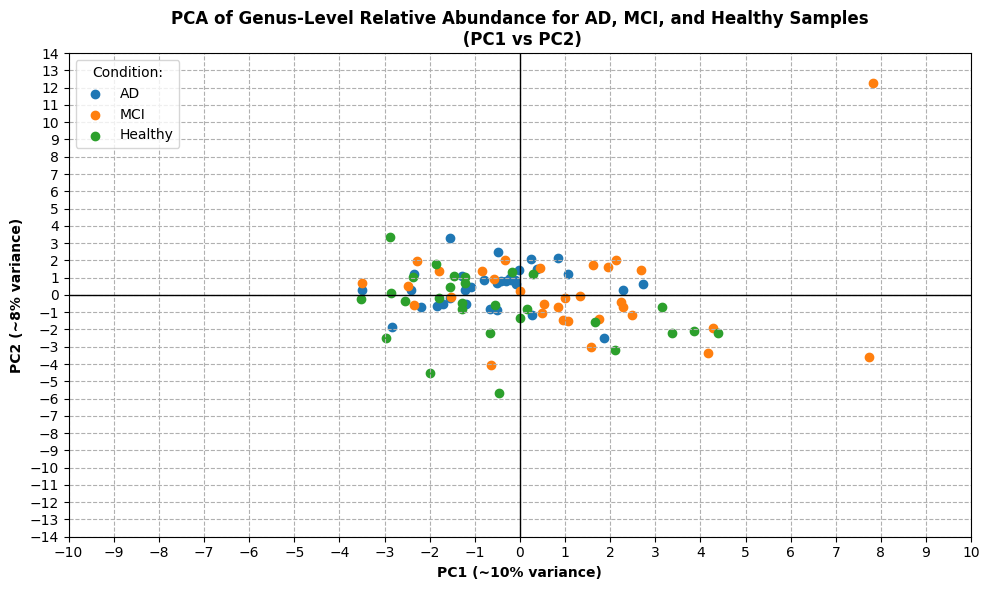

In [ ]:
# Plot PC1 vs PC2
plt.figure(figsize=(10, 6))
conditions = ["AD", "MCI", "Healthy"]

for condition in conditions:
    condition_pca = pca_df[pca_df["condition"] == condition]
    plt.scatter(condition_pca["PC1"],
                condition_pca["PC2"],
                label = condition)

plt.xlabel("PC1 (~10% variance)", fontweight = "bold")
plt.ylabel("PC2 (~8% variance)", fontweight = "bold")
plt.title("PCA of Genus-Level Relative Abundance for AD, MCI, and Healthy Samples\n (PC1 vs PC2)", fontweight = "bold")
plt.legend(title = "Condition:")
plt.xticks(np.arange(-10, 11, 1))
plt.axhline(0, color = "black", linewidth = 1)
plt.yticks(np.arange(-14, 15, 1))
plt.axvline(0, color = "black", linewidth = 1)
plt.grid(True, linestyle = "--")
plt.tight_layout()
plt.show()

In [ ]:
# Select genera with greatest ICR and store in a list.
top_genera = icr.head(5).index.tolist()
# Find relative abundance for top genera.
top_rel_abd = rel_abd_matrix[top_genera].copy()
# Add sample ID column.
top_rel_abd["sample_id"] = top_rel_abd.index
# Reset index.
top_rel_abd = top_rel_abd.reset_index(drop=True)

print(top_rel_abd)

genus  Escherichia  Bacteroides   Blautia  Alistipes  Limosilactobacillus  \
0         0.000000     0.000000  0.061740   0.000000             0.563767   
1         0.509391     0.030804  0.084899   0.000000             0.000000   
2         0.294271     0.039062  0.057726   0.011285             0.016059   
3         0.841240     0.000000  0.011743   0.000000             0.020667   
4         0.000000     0.000000  0.105855   0.000000             0.000000   
..             ...          ...       ...        ...                  ...   
88        0.178281     0.069683  0.033786   0.015686             0.012066   
89        0.295258     0.117632  0.025413   0.079644             0.000000   
90        0.183633     0.035928  0.074850   0.000000             0.000000   
91        0.028533     0.049457  0.129620   0.013315             0.036141   
92        0.000000     0.241268  0.111903   0.109145             0.000000   

genus   sample_id  
0      SRR8061715  
1      SRR8061716  
2      SRR80617

Machine Learning RA Features

In [ ]:
# Merge with top relative abundance and PCA dataframes to get ML features.
features = pca_df.merge(top_rel_abd, on="sample_id")
# Reorder columns.
cols = ["sample_id", "condition"] + [col for col in features.columns if col not in ["sample_id", "condition"]]
features = features[cols]

print(features.head())

    sample_id condition       PC1       PC2       PC3  Escherichia  \
0  SRR8061715        AD -2.420204  0.264267  2.695112     0.000000   
1  SRR8061716        AD -0.305117  0.802686  3.401735     0.509391   
2  SRR8061717        AD -0.655024 -0.822020  0.503503     0.294271   
3  SRR8061718        AD -0.517932  0.679205  3.005779     0.841240   
4  SRR8061719        AD -2.342568  1.186368  1.623629     0.000000   

   Bacteroides   Blautia  Alistipes  Limosilactobacillus  
0     0.000000  0.061740   0.000000             0.563767  
1     0.030804  0.084899   0.000000             0.000000  
2     0.039062  0.057726   0.011285             0.016059  
3     0.000000  0.011743   0.000000             0.020667  
4     0.000000  0.105855   0.000000             0.000000  


In [ ]:
# Create folder for Machine Learning Analysis
ml_analysis_path = "/content/drive/MyDrive/Machine_Learning"
os.makedirs(ml_analysis_path, exist_ok=True)

In [ ]:
# Export Relative Abundance Features to folder
save_path = Path(ml_analysis_path) / "relative_abundance_features.csv"
features.to_csv(save_path, index=False)